# Model Predictions (qubit_TransmonCross_cap_matrix)
## Capacitance --> Qiskit Metal

Inverse model with surrogate-defined loss

## Configuration

In [5]:
# The parameter file is where the hyperparameters are set. 
# It's reccomended to look at that file first, its interesting and you can set stuff there

from parameters_surrogate_defined_loss import *

## Library

In [6]:
import os, gc, math
from pathlib import Path
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense

## Dataset

### Load

In [7]:
# Load the data saved from ml_00 notebook

# inputs are the capacitance values (what we want to invert)
X_train = np.load(f'{DATA_DIR}/npy/x_train_one_hot_encoding_augmented.npy', allow_pickle=True)
X_val   = np.load(f'{DATA_DIR}/npy/x_val_one_hot_encoding_augmented.npy', allow_pickle=True)
X_test  = np.load(f'{DATA_DIR}/npy/x_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# Qiskit Metal params (all continuous for transmon cross)
y_train = np.load(f'{DATA_DIR}/npy/y_train_one_hot_encoding_augmented.npy', allow_pickle=True)
y_val   = np.load(f'{DATA_DIR}/npy/y_val_one_hot_encoding_augmented.npy', allow_pickle=True)
y_test  = np.load(f'{DATA_DIR}/npy/y_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# column names
with open('X_names', 'r') as f:
    cap_column_names = f.read().splitlines()

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

print(f'Inputs (Capacitance):     {X_train.shape[1]} columns')
print(f'Outputs (Qiskit params):  {y_train.shape[1]} columns')
print(f'\nCapacitance columns:  {cap_column_names}')
print(f'Qiskit param columns: {qiskit_param_names}')

Inputs (Capacitance):     6 columns
Outputs (Qiskit params):  3 columns

Capacitance columns:  ['cross_to_ground', 'claw_to_ground', 'cross_to_claw', 'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
Qiskit param columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']


### Define conversion layer

In [8]:
# Must define this class before loading the saved combined model
class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault('trainable', False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = dict(
            scale_a=list(scale_a) if hasattr(scale_a, '__iter__') else scale_a,
            scale_b=list(scale_b) if hasattr(scale_b, '__iter__') else scale_b)

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

### Visualize model

In [9]:
# Decide which model file to use
encoding = 'surrogate_defined_loss'
chosen_path = f'model/best_keras_model_{encoding}.keras'
X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)

# Load output headers (capacitance column names — the reconstruction target)
headers = cap_column_names
print(f'Model path: {chosen_path}')
print(f'Capacitance output headers: {headers}')

Model path: model/best_keras_model_surrogate_defined_loss.keras
Capacitance output headers: ['cross_to_ground', 'claw_to_ground', 'cross_to_claw', 'cross_to_cross', 'claw_to_claw', 'ground_to_ground']


In [10]:
#look at the best model, ooh so pretty
tf.keras.backend.clear_session()
gc.collect()
try:
    tf.config.experimental.reset_memory_stats('GPU:0')
except Exception:
    pass

with tf.device('/CPU:0'):
    combined_model = load_model(chosen_path, compile=False,
        custom_objects={'ScalerConversionLayer': ScalerConversionLayer})
    inverse_model = combined_model.get_layer('inverse_model')
    
    # get both the reconstructed capacitance and the predicted Qiskit params
    predictions = combined_model.predict(X_test_cur, verbose=0)
    if isinstance(predictions, list):
        cap_pred = predictions[0]
        qiskit_pred = predictions[1]
    else:
        cap_pred = predictions
        qiskit_pred = inverse_model.predict(X_test_cur, verbose=0)

print(f'\n—— {os.path.basename(chosen_path)} ——')
print('\nCombined model (inverse + conversion + frozen surrogate):')
combined_model.summary()
print('\nInverse model only:')
inverse_model.summary()
print(f'\nSamples: {len(X_test_cur)} | Cap targets dim: {X_test_cur.shape[1]} | Qiskit dim: {y_test_cur.shape[1]}')

I0000 00:00:1773100957.301125  267794 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 607 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:08:00.0, compute capability: 8.0



—— best_keras_model_surrogate_defined_loss.keras ——

Combined model (inverse + conversion + frozen surrogate):


I0000 00:00:1773100957.627328  272670 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 3)              │           643 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaler_conversion               │ (None, 3)              │             0 │
│ (ScalerConversionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 6)              │         3,526 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_output (Dense)           │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643 (2.51 KB)

 Trainable params: 643 (2.51 KB)

 Non-trainable params: 0 (0.00 B)


Samples: 291 | Cap targets dim: 6 | Qiskit dim: 3


In [11]:
# look at some more specific model params
inv = combined_model.get_layer('inverse_model')

neurons_per_layer = [
    l.units for l in inv.layers
    if isinstance(l, Dense) and l.name.startswith('fc')
]
print('Best NEURONS_PER_LAYER:', neurons_per_layer)

dropouts = [
    (l.name, float(l.rate)) for l in inv.layers
    if isinstance(l, tf.keras.layers.Dropout)
]
if dropouts:
    print('Best DROPOUT rate(s):', dropouts)
else:
    print('Best DROPOUT rate(s): none found')

Best NEURONS_PER_LAYER: [64]
Best DROPOUT rate(s): [('dropout0', 0.0)]


# Scaled

In [12]:
N_SAMPLES_TO_SHOW = 50 # change this to print more stuff

X_test_cur = np.asarray(X_test_cur)
y_test_cur = np.asarray(y_test_cur)
cap_pred   = np.asarray(cap_pred)
qiskit_pred = np.asarray(qiskit_pred)

N, P = X_test_cur.shape  # P = number of capacitance columns

# scaled errors on capacitance reconstruction
cap_abs_errors = np.abs(X_test_cur - cap_pred)
cap_sq_errors  = (X_test_cur - cap_pred) ** 2

# building dataframe for cap reconstruction
rows = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(P):
        label = headers[j] if j < len(headers) else f'cap_col_{j}'
        rows.append({
            'sample_idx': i,
            'param': label,
            'ref':  X_test_cur[i, j],
            'pred': cap_pred[i, j],
            'abs_error': cap_abs_errors[i, j],
            'sq_error':  cap_sq_errors[i, j],
        })

df = pd.DataFrame(rows)

# save scaled predictions
out_csv = Path(f'surrogate_loss_cap_reconstruction_scaled_{encoding}.csv')
df.to_csv(out_csv, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # capacitance reconstruction table
    sub = df[df['sample_idx'] == i].copy()
    sub = sub[['param', 'ref', 'pred', 'abs_error', 'sq_error']]
    print(f'— Sample {i} — Capacitance reconstruction (scaled)')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this capacitance
    print(f'\n  Predicted Qiskit Metal params (scaled):')
    for j, col_name in enumerate(qiskit_param_names):
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred[i, j]
        ref_val  = y_test_cur[i, j]
        print(f'    {short_name:40s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    print()

print('Global scaled cap reconstruction error stats:')
print('  min abs_error:', float(cap_abs_errors.min()))
print('  median abs_error:', float(np.median(cap_abs_errors)))
print('  max abs_error:', float(cap_abs_errors.max()))

Saved CSV -> /home/olivias/ML_qubit_design/model_predict_qubit_TransmonCross_cap_matrix/surrogate_loss_cap_reconstruction_scaled_surrogate_defined_loss.csv

— Sample 0 — Capacitance reconstruction (scaled)
           param      ref     pred  abs_error     sq_error
 cross_to_ground 0.491077 0.491418   0.000341 1.163822e-07
  claw_to_ground 0.333713 0.334445   0.000732 5.354878e-07
   cross_to_claw 0.324772 0.323355   0.001417 2.008686e-06
  cross_to_cross 0.491077 0.491276   0.000199 3.964499e-08
    claw_to_claw 0.339820 0.340507   0.000686 4.712500e-07
ground_to_ground 0.450407 0.445164   0.005243 2.748674e-05

  Predicted Qiskit Metal params (scaled):
    connection_pads.readout.claw_length       pred=0.33197689056396484  ref=0.33333333333333337  err=0.0013564427693685266
    connection_pads.readout.ground_spacing    pred=0.17392206192016602  ref=0.15254237288135597  err=0.021379689038810046
    cross_length                              pred=0.5184445381164551  ref=0.5151515151515151

# Unscaled

In [13]:
# Unscale everything and look at errors in real units that we can actually understand

with open('X_names', 'r') as f:
    cap_names = f.read().splitlines()
qiskit_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

# Unscale input capacitance using X scalers
x_scaler_prefix = 'scaler_X'

X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]

# Unscale reconstructed capacitance using same X scalers
cap_pred_unscaled = np.asarray(cap_pred.copy())
for i in range(cap_pred_unscaled.shape[0]):
    for j in range(cap_pred_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        cap_pred_unscaled[i, j] = scaler.inverse_transform([[cap_pred_unscaled[i, j]]])[0][0]

# Unscale Qiskit param predictions (using ml_00 scalers)
qiskit_pred_unscaled = np.asarray(qiskit_pred.copy())
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(qiskit_pred_unscaled.shape[0]):
    for j in range(qiskit_pred_unscaled.shape[1]):
        col_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/scaler_y_{col_name}_one_hot_encoding.save')
        qiskit_pred_unscaled[i, j] = scaler.inverse_transform([[qiskit_pred_unscaled[i, j]]])[0][0]
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]

n_samples, n_cap_params = X_test_unscaled.shape

# Errors on cap reconstruction (unscaled)
cap_abs_errors_unscaled = np.abs(X_test_unscaled - cap_pred_unscaled)
cap_sq_errors_unscaled  = (X_test_unscaled - cap_pred_unscaled) ** 2

# Build dataframe
rows_unscaled = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(n_cap_params):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        rows_unscaled.append({
            'sample_idx': i,
            'param': cap_name,
            'ref_unscaled': X_test_unscaled[i, j],
            'pred_unscaled': cap_pred_unscaled[i, j],
            'abs_error_unscaled': cap_abs_errors_unscaled[i, j],
            'sq_error_unscaled': cap_sq_errors_unscaled[i, j],
        })

df_unscaled = pd.DataFrame(rows_unscaled)

# Save
out_csv_unscaled = Path(f'surrogate_loss_cap_reconstruction_unscaled_{encoding}.csv')
df_unscaled.to_csv(out_csv_unscaled, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv_unscaled.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # capacitance reconstruction table
    sub = df_unscaled[df_unscaled['sample_idx'] == i].copy()
    sub = sub[['param', 'ref_unscaled', 'pred_unscaled', 'abs_error_unscaled', 'sq_error_unscaled']]
    print(f'— Sample {i} (Unscaled) — Capacitance reconstruction')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this capacitance
    print(f'\n  Predicted Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred_unscaled[i, j]
        ref_val  = y_test_unscaled[i, j]
        print(f'    {short_name:40s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    
    # reference Qiskit params
    print(f'\n  Reference Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short_name = col_name.replace('design_options.', '')
        print(f'    {short_name:40s}  ref={y_test_unscaled[i, j]}')
    print()

print('Global unscaled cap reconstruction error stats:')
print('  min abs_error:', float(cap_abs_errors_unscaled.min()))
print('  median abs_error:', float(np.median(cap_abs_errors_unscaled)))
print('  max abs_error:', float(cap_abs_errors_unscaled.max()))

Saved CSV -> /home/olivias/ML_qubit_design/model_predict_qubit_TransmonCross_cap_matrix/surrogate_loss_cap_reconstruction_unscaled_surrogate_defined_loss.csv

— Sample 0 (Unscaled) — Capacitance reconstruction
           param  ref_unscaled  pred_unscaled  abs_error_unscaled  sq_error_unscaled
 cross_to_ground     133.51715     133.581512            0.064362           0.004143
  claw_to_ground      96.70298      96.794426            0.091446           0.008362
   cross_to_claw       5.98705       5.967897            0.019153           0.000367
  cross_to_cross     133.51715     133.554718            0.037568           0.001411
    claw_to_claw     103.12264     103.214592            0.091952           0.008455
ground_to_ground     287.80599     286.044098            1.761892           3.104264

  Predicted Qiskit Metal params (unscaled):
    connection_pads.readout.claw_length       pred=0.00017955237126443535  ref=0.00018  err=4.4762873556466044e-07
    connection_pads.readout.ground_

## Visualize Results

Lets see how good we actually did

In [14]:
# === Percentage error: surrogate-reconstructed capacitance vs actual input capacitance ===
eps = 1e-15
pct_errors_unscaled = 100.0 * np.abs(cap_pred_unscaled - X_test_unscaled) / (np.abs(X_test_unscaled) + eps)

short_names = [c.split('.')[-1] if '.' in c else c for c in cap_names[:n_cap_params]]
data_per_col = [pct_errors_unscaled[:, j] for j in range(n_cap_params)]
all_pct = pct_errors_unscaled.ravel()

print(f'This is: |surrogate(predicted_qiskit_params) - actual_capacitance| / |actual_capacitance| * 100')
print(f'Samples: {n_samples}, Capacitance columns: {n_cap_params}')

This is: |surrogate(predicted_qiskit_params) - actual_capacitance| / |actual_capacitance| * 100
Samples: 291, Capacitance columns: 6


/tmp/ipykernel_267794/1897351026.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,


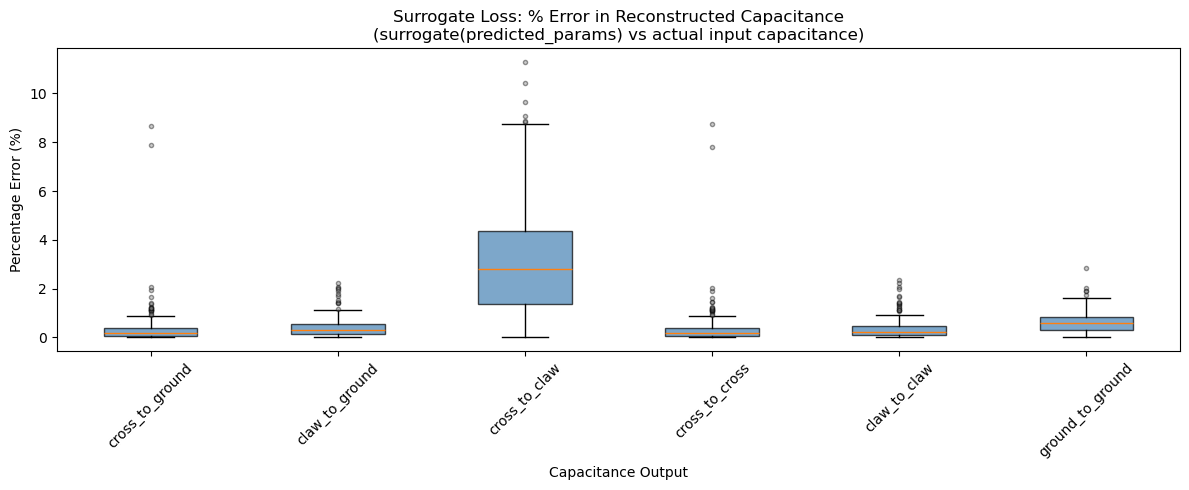

In [15]:
# box plot showing % error distribution per capacitance output 
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='grey'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('Capacitance Output')
ax.set_title('Surrogate Loss: % Error in Reconstructed Capacitance\n(surrogate(predicted_params) vs actual input capacitance)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_cap_recon_pct_error_boxplot.pdf')
plt.show()

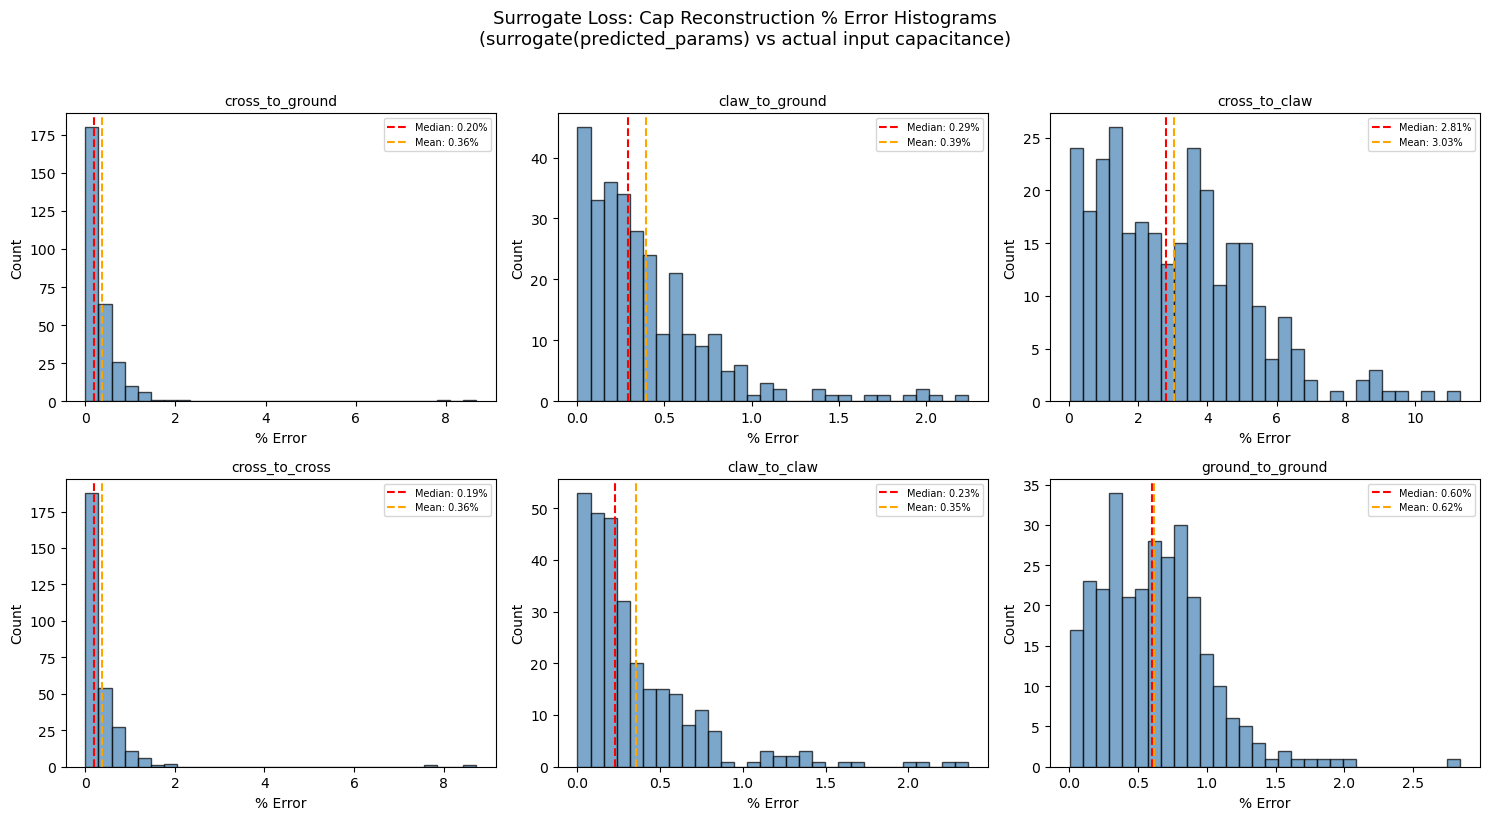

In [16]:
# histogram it too
n_cols_grid = 3
n_rows_grid = math.ceil(n_cap_params / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.ravel()

for j in range(n_cap_params):
    col_pct = pct_errors_unscaled[:, j]
    ax = axes[j]
    ax.hist(col_pct, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.median(col_pct), color='red', linestyle='--',
               label=f'Median: {np.median(col_pct):.2f}%')
    ax.axvline(np.mean(col_pct), color='orange', linestyle='--',
               label=f'Mean: {np.mean(col_pct):.2f}%')
    ax.set_title(short_names[j], fontsize=10)
    ax.set_xlabel('% Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

for k in range(n_cap_params, len(axes)):
    fig.delaxes(axes[k])

fig.suptitle('Surrogate Loss: Cap Reconstruction % Error Histograms\n(surrogate(predicted_params) vs actual input capacitance)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_cap_recon_pct_error_histograms.pdf')
plt.show()

In [17]:
#look at the stats nicely
print('Capacitance Reconstruction % Error: surrogate(predicted_params) vs actual input capacitance')
print()
print(f"{'Output':<25s} {'Median %':>10s} {'Mean %':>10s} {'90th %':>10s} {'Max %':>10s}")
print('-' * 70)
for j in range(n_cap_params):
    col_pct = pct_errors_unscaled[:, j]
    name = short_names[j]
    print(f"{name:<25s} {np.median(col_pct):10.2f} {np.mean(col_pct):10.2f} "
          f"{np.percentile(col_pct, 90):10.2f} {np.max(col_pct):10.2f}")
print('-' * 70)
print(f"{'All outputs':<25s} {np.median(all_pct):10.2f} {np.mean(all_pct):10.2f} "
      f"{np.percentile(all_pct, 90):10.2f} {np.max(all_pct):10.2f}")

Capacitance Reconstruction % Error: surrogate(predicted_params) vs actual input capacitance

Output                      Median %     Mean %     90th %      Max %
----------------------------------------------------------------------
cross_to_ground                 0.20       0.36       0.78       8.68
claw_to_ground                  0.29       0.39       0.81       2.25
cross_to_claw                   2.81       3.03       5.62      11.31
cross_to_cross                  0.19       0.36       0.80       8.73
claw_to_claw                    0.23       0.35       0.77       2.36
ground_to_ground                0.60       0.62       1.10       2.84
----------------------------------------------------------------------
All outputs                     0.35       0.85       2.25      11.31


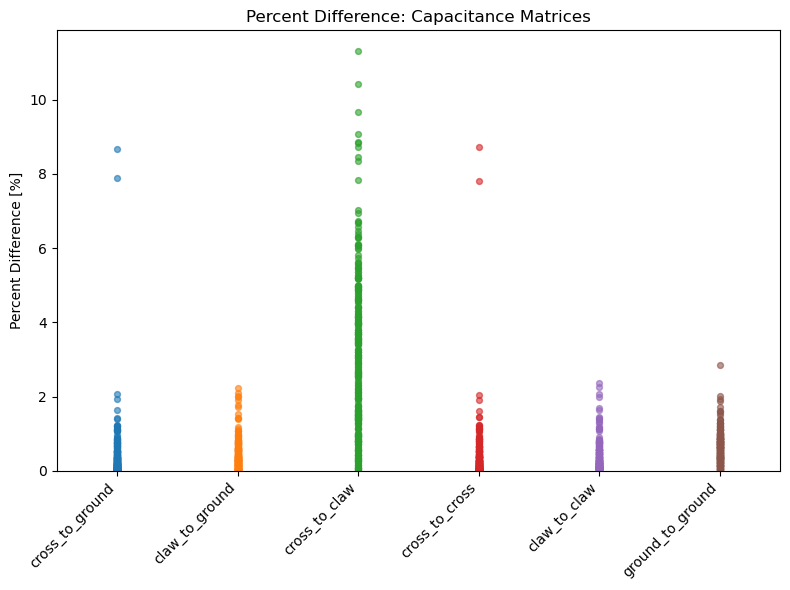

In [18]:
# scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
for j in range(n_cap_params):
    col_pct = pct_errors_unscaled[:, j]
    ax.scatter(np.full(len(col_pct), j), col_pct, s=18, alpha=0.6)
ax.set_xticks(range(n_cap_params))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Percent Difference [%]')
ax.set_title('Percent Difference: Capacitance Matrices')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, n_cap_params - 0.5)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_cap_recon_pct_scatter.pdf')
plt.show()

## Ansys Results

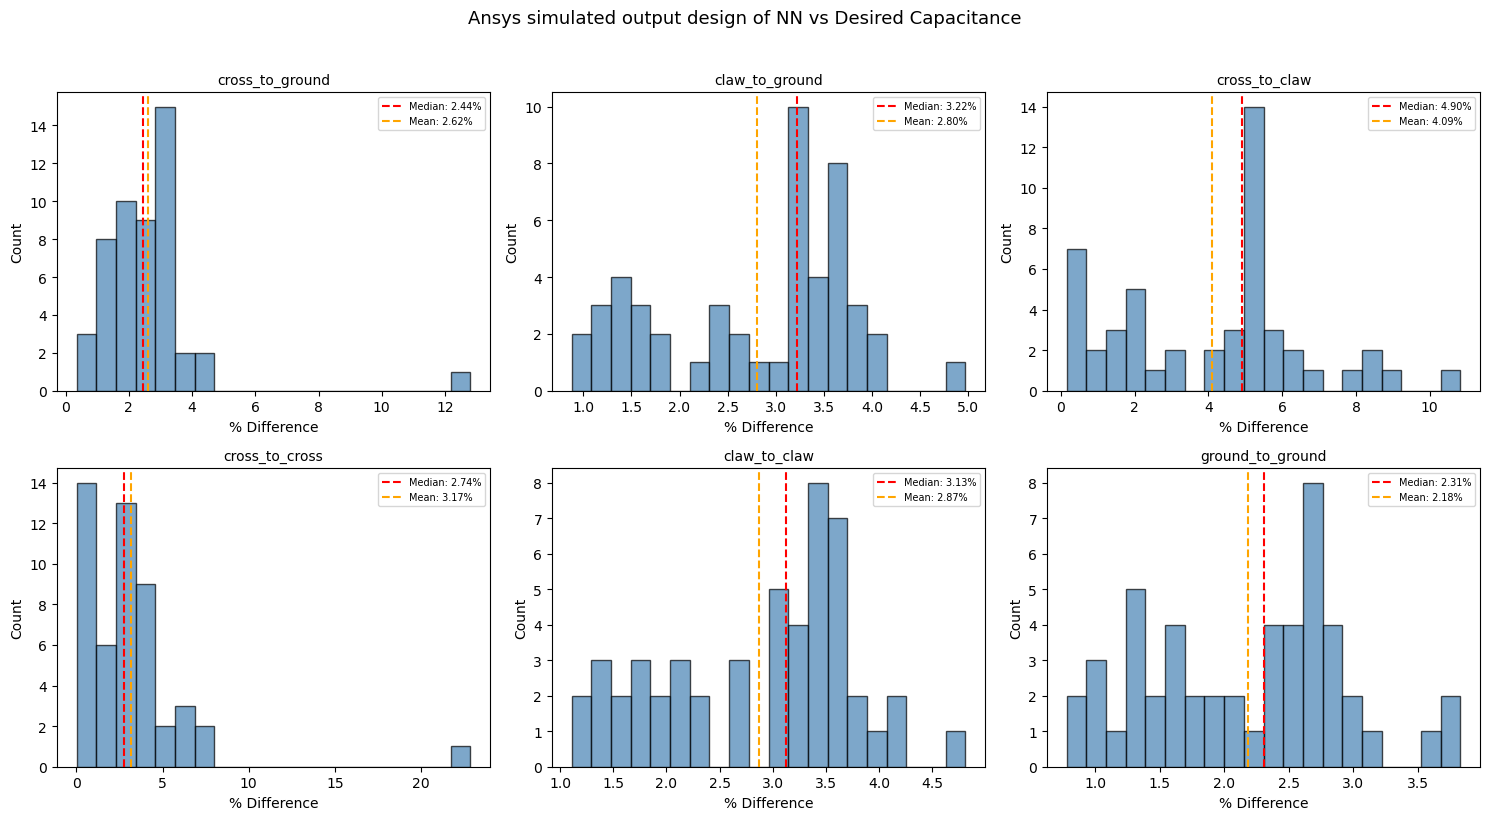

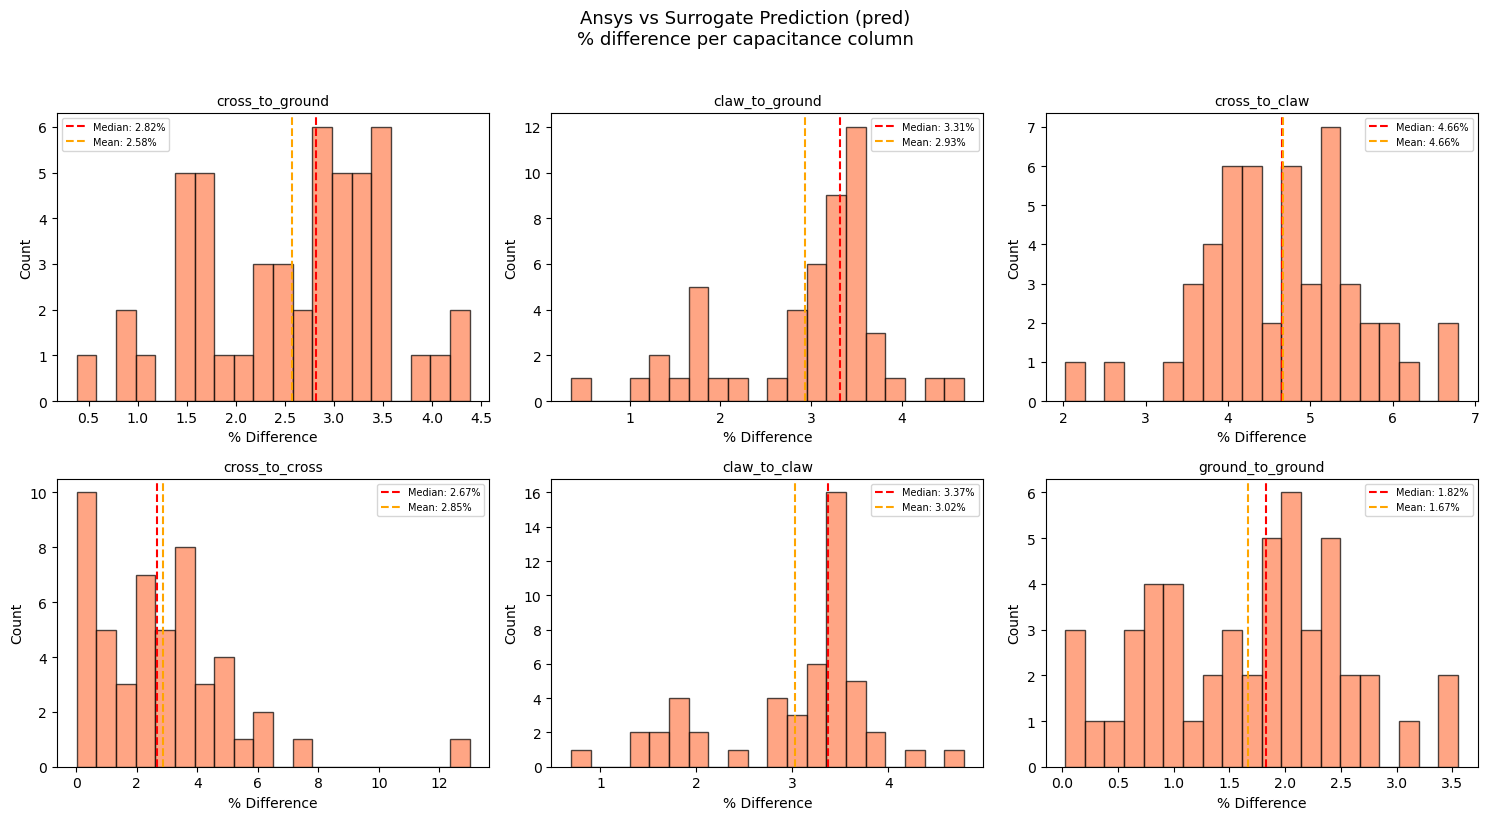

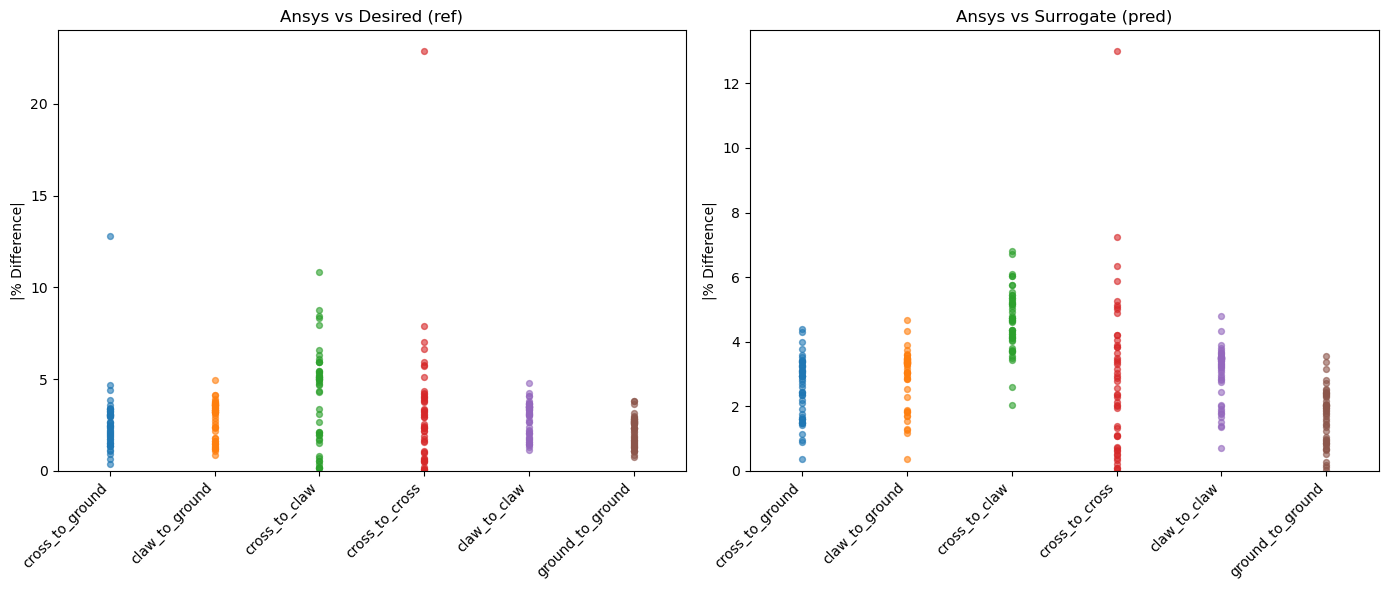

=== Ansys vs Desired Capacitance (ref) ===
Param                  Median %     Mean %    Max |%|
-------------------------------------------------------
cross_to_ground            2.44       2.62      12.80
claw_to_ground             3.22       2.80       4.97
cross_to_claw              4.90       4.09      10.83
cross_to_cross             2.74       3.17      22.86
claw_to_claw               3.13       2.87       4.81
ground_to_ground           2.31       2.18       3.83

=== Ansys vs Surrogate Prediction (pred) ===
Param                  Median %     Mean %    Max |%|
-------------------------------------------------------
cross_to_ground            2.82       2.58       4.38
claw_to_ground             3.31       2.93       4.68
cross_to_claw              4.66       4.66       6.79
cross_to_cross             2.67       2.85      12.99
claw_to_claw               3.37       3.02       4.79
ground_to_ground           1.82       1.67       3.55


In [23]:
df = pd.read_csv('ML_with_Ansys_results_for_combined_models.csv')
cap_names = df['param'].unique()
eps = 1e-15

# Compute % errors for both comparisons
df['pct_ansys_vs_ref'] = abs(100 * (df['ansys_unscaled'] - df['ref_unscaled']) / (np.abs(df['ref_unscaled']) + eps))
df['pct_ansys_vs_pred'] = abs(100 * (df['ansys_unscaled'] - df['pred_unscaled']) / (np.abs(df['pred_unscaled']) + eps))

# --- PLOT 1: Ansys vs Ref (desired cap) per capacitance column ---
n_caps = len(cap_names)
n_cols_grid = 3
n_rows_grid = math.ceil(n_caps / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.ravel()
for j, cap in enumerate(cap_names):
    sub = df[df['param'] == cap]
    ax = axes[j]
    ax.hist(sub['pct_ansys_vs_ref'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(sub['pct_ansys_vs_ref'].median(), color='red', linestyle='--',
               label=f'Median: {sub["pct_ansys_vs_ref"].median():.2f}%')
    ax.axvline(sub['pct_ansys_vs_ref'].mean(), color='orange', linestyle='--',
               label=f'Mean: {sub["pct_ansys_vs_ref"].mean():.2f}%')
    ax.set_title(cap, fontsize=10)
    ax.set_xlabel('% Difference')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
for k in range(n_caps, len(axes)):
    fig.delaxes(axes[k])
fig.suptitle('Ansys simulated output design of NN vs Desired Capacitance', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/ansys_vs_ref_histograms.pdf')
plt.show()

# --- PLOT 2: Ansys vs Surrogate Prediction per capacitance column ---
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.ravel()
for j, cap in enumerate(cap_names):
    sub = df[df['param'] == cap]
    ax = axes[j]
    ax.hist(sub['pct_ansys_vs_pred'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(sub['pct_ansys_vs_pred'].median(), color='red', linestyle='--',
               label=f'Median: {sub["pct_ansys_vs_pred"].median():.2f}%')
    ax.axvline(sub['pct_ansys_vs_pred'].mean(), color='orange', linestyle='--',
               label=f'Mean: {sub["pct_ansys_vs_pred"].mean():.2f}%')
    ax.set_title(cap, fontsize=10)
    ax.set_xlabel('% Difference')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
for k in range(n_caps, len(axes)):
    fig.delaxes(axes[k])
fig.suptitle('Ansys vs Surrogate Prediction (pred)\n% difference per capacitance column', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/ansys_vs_pred_histograms.pdf')
plt.show()

# --- PLOT 3: Scatter plots side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for j, cap in enumerate(cap_names):
    sub = df[df['param'] == cap]
    ax1.scatter(np.full(len(sub), j), sub['pct_ansys_vs_ref'].abs(), s=18, alpha=0.6)
    ax2.scatter(np.full(len(sub), j), sub['pct_ansys_vs_pred'].abs(), s=18, alpha=0.6)

for ax, title in [(ax1, 'Ansys vs Desired (ref)'), (ax2, 'Ansys vs Surrogate (pred)')]:
    ax.set_xticks(range(n_caps))
    ax.set_xticklabels(cap_names, rotation=45, ha='right')
    ax.set_ylabel('|% Difference|')
    ax.set_title(title)
    ax.set_ylim(0, None)
    ax.margins(y=0)
    ax.set_xlim(-0.5, n_caps - 0.5)

plt.tight_layout()
plt.savefig('plots/ansys_scatter_comparison.pdf')
plt.show()

# --- Stats table ---
print('=== Ansys vs Desired Capacitance (ref) ===')
print(f'{"Param":<20s} {"Median %":>10s} {"Mean %":>10s} {"Max |%|":>10s}')
print('-' * 55)
for cap in cap_names:
    sub = df[df['param'] == cap]['pct_ansys_vs_ref']
    print(f'{cap:<20s} {sub.median():10.2f} {sub.mean():10.2f} {sub.abs().max():10.2f}')

print()
print('=== Ansys vs Surrogate Prediction (pred) ===')
print(f'{"Param":<20s} {"Median %":>10s} {"Mean %":>10s} {"Max |%|":>10s}')
print('-' * 55)
for cap in cap_names:
    sub = df[df['param'] == cap]['pct_ansys_vs_pred']
    print(f'{cap:<20s} {sub.median():10.2f} {sub.mean():10.2f} {sub.abs().max():10.2f}')